<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/_train_1s_30hz_initial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SimCLR Training

In [7]:
# For VSCode
%load_ext autoreload
%autoreload 2

import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt

sys.path.append('../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

with open('../data_1s_30hz/TrainTest/X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('../data_1s_30hz/TrainTest/y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('../data_1s_30hz/TrainTest/X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('../data_1s_30hz/TrainTest/y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('../data_1s_30hz/TrainTest/X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('../data_1s_30hz/TrainTest/y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

np_train_data.shape, np_train_labels.shape, np_val_data.shape, np_val_labels.shape, np_test_labels.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


((2640, 30, 3), (2640, 7), (660, 30, 3), (660, 7), (825, 7))

In [3]:
# For Google Colab
# 1. Clone your repository to go to access your notebook and .py files
!git clone https://github.com/Ziyi-star/Bachelorarbeit.git
# 2. Change working directory to where your notebook and .py files are
import os
os.chdir('/content/Bachelorarbeit/notebooks/training')
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import simclr_utitlities
import transformations
import simclr_models
import sys
sys.path.append('../../')
from utils.preprocessing import *



seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load data
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/X_train_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/y_train_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/X_val_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/y_val_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/X_test_data.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/y_test_onehot.pkl


working_directory = "../models/"  # Relative path to models folder

# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

print(np_train_data.shape, np_train_labels.shape)
print(np_val_data.shape, np_val_labels.shape)

fatal: destination path 'Bachelorarbeit' already exists and is not an empty directory.
--2025-09-30 13:46:47--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1900965 (1.8M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]   1.81M  --.-KB/s    in 0.04s   

2025-09-30 13:46:48 (43.8 MB/s) - ‘X_train_normalized.pkl’ saved [1900965/1900965]

--2025-09-30 13:46:48--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/y_train_onehot.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 18

## 1.1 Pretraining with SimCLR

In [8]:
# Parameters for all experiments
window_size = 30
input_shape = (window_size, 3)
batch_size = 512
#Number of samples processed together in one training step. Larger batch sizes can speed up training but require more memory.
decay_steps = 1000
#Number of steps after which the learning rate decays (used for learning rate scheduling).
epochs = 200
temperature = 0.1


In [9]:
#A parameter for the SimCLR loss function that controls how sharply similarities are measured.
# transform_funcs = [
#     transformations.scaling_transform_vectorized, # Use Scaling trasnformation
#     transformations.rotation_transform_vectorized # Use rotation trasnformation
# ]
transform_funcs = [
    transformations.time_segment_permutation_transform_improved,
    transformations.channel_shuffle_transform_vectorized
]
#List of data augmentation functions to apply to the input data. Here, only rotation is used.
transformation_function = simclr_utitlities.generate_composite_transform_function_simple(transform_funcs)

0 <function time_segment_permutation_transform_improved at 0x000002A685D914E0>
1 <function channel_shuffle_transform_vectorized at 0x000002A685D91440>


In [10]:
# Time
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
#Formats the date and time as a string like 20250827-153045 (for filenames, logs, etc.).
tf.keras.backend.set_floatx('float32')
#Sets TensorFlow to use 32-bit floating point numbers for all computations (standard for deep learning).


In [11]:
# Create a cosine-decayed learning rate schedule and SGD optimizer for training.
lr_decayed_fn = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.1, decay_steps=decay_steps)
optimizer = tf.keras.optimizers.SGD(lr_decayed_fn)

# Build the base model and attach the SimCLR head for contrastive learning.
base_model = simclr_models.create_base_model_small_dimensions(input_shape, model_name="base_model")
simclr_model = simclr_models.attach_simclr_head(base_model)
simclr_model.summary()

# Train the SimCLR model using the specified transformation function and optimizer.
trained_simclr_model, epoch_losses = simclr_utitlities.simclr_train_model(
    simclr_model,
    np_train_data,
    optimizer,
    batch_size,
    transformation_function,
    temperature=temperature,
    epochs=epochs,
    is_trasnform_function_vectorized=True,
    verbose=1
)

# Save the trained SimCLR model to disk for later use.
simclr_model_save_path = f"{working_directory}{start_time_str}_simclr.hdf5"
trained_simclr_model.save(simclr_model_save_path)

Model: "base_model_simclr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,594 (580.45 KB)

 Trainable params: 148,594 (580.45 KB)

 Non-trainable params: 0 (0.00 B)

epoch: 1 loss: 12.237
epoch: 2 loss: 11.195
epoch: 3 loss: 11.200
epoch: 4 loss: 9.671
epoch: 5 loss: 9.473
epoch: 6 loss: 9.382
epoch: 7 loss: 9.081
epoch: 8 loss: 9.203
epoch: 9 loss: 8.659
epoch: 10 loss: 8.463
epoch: 11 loss: 8.201
epoch: 12 loss: 8.710
epoch: 13 loss: 8.732
epoch: 14 loss: 7.612
epoch: 15 loss: 7.372
epoch: 16 loss: 7.037
epoch: 17 loss: 6.782
epoch: 18 loss: 6.771
epoch: 19 loss: 6.611
epoch: 20 loss: 6.358
epoch: 21 loss: 6.052
epoch: 22 loss: 6.584
epoch: 23 loss: 6.356
epoch: 24 loss: 6.109
epoch: 25 loss: 6.679
epoch: 26 loss: 6.271
epoch: 27 loss: 5.869
epoch: 28 loss: 5.843
epoch: 29 loss: 5.530
epoch: 30 loss: 5.329
epoch: 31 loss: 5.653
epoch: 32 loss: 5.449
epoch: 33 loss: 5.222
epoch: 34 loss: 5.672
epoch: 35 loss: 5.909
epoch: 36 loss: 5.177
epoch: 37 loss: 4.966
epoch: 38 loss: 5.033
epoch: 39 loss: 4.891
epoch: 40 loss: 4.797
epoch: 41 loss: 5.108
epoch: 42 loss: 4.701
epoch: 43 loss: 4.860
epoch: 44 loss: 5.159
epoch: 45 loss: 4.676
epoch: 46 loss: 

epoch: 200 loss: 2.203


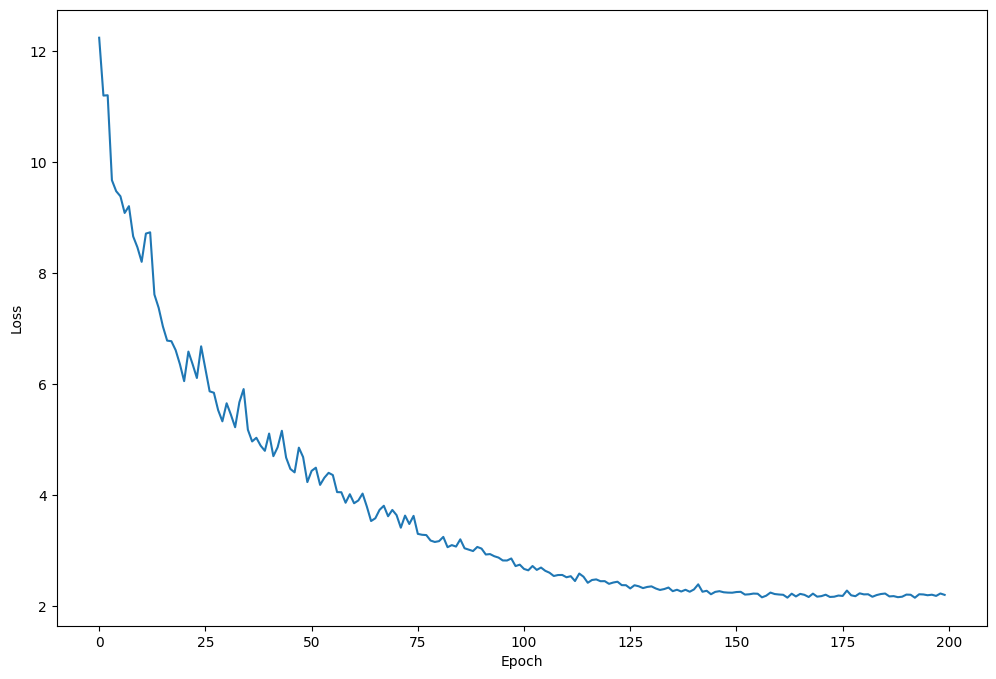

In [12]:
# Plot history of training losses over epochs.
plt.figure(figsize=(12,8))
plt.plot(epoch_losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

## 1.2 Fine-tuning and Evaluation

### 1.2.1 Linear Model

#### Train

In [13]:
# This block performs linear evaluation on top of the pretrained SimCLR base model.
total_epochs = 50
batch_size = 200
tag = "linear_eval"
output_shape = np_train_labels.shape[1]  # Number of classes for classification

# 1. Loads the SimCLR model and attaches a linear classification head on top.
simclr_model = tf.keras.models.load_model(simclr_model_save_path)
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

# 2. Sets up a ModelCheckpoint callback to save the best model (lowest validation loss).
# This ensures we keep the model version that performs best on validation data
linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(
    linear_eval_best_model_file_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

# 3. Trains the linear evaluation model using the training and validation data.
training_history = linear_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - auc: 0.6803 - categorical_accuracy: 0.2843 - loss: 1.7571 - precision: 0.6880 - recall: 0.0917 - val_auc: 0.7970 - val_categorical_accuracy: 0.4379 - val_loss: 1.5026 - val_precision: 0.9343 - val_recall: 0.1939
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - auc: 0.8058 - categorical_accuracy: 0.4444 - loss: 1.5075 - precision: 0.8609 - recall: 0.1603 - val_auc: 0.8215 - val_categorical_accuracy: 0.4576 - val_loss: 1.4283 - val_precision: 0.9122 - val_recall: 0.2045
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.8220 - categorical_accuracy: 0.4641 - loss: 1.4461 - precision: 0.8563 - recall: 0.1676 - val_auc: 0.8313 - val_categorical_accuracy: 0.4864 - val_loss: 1.3894 - val_precision: 0.9032 - val_recall: 0.2121
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc: 0.8282 - categorical_accuracy: 0.4747 - loss: 1.4150 - precision: 0.8350 - recall: 0.1776 - val_auc: 0.8367 - val_categorical_accuracy: 0.5076 - val_loss: 1.3

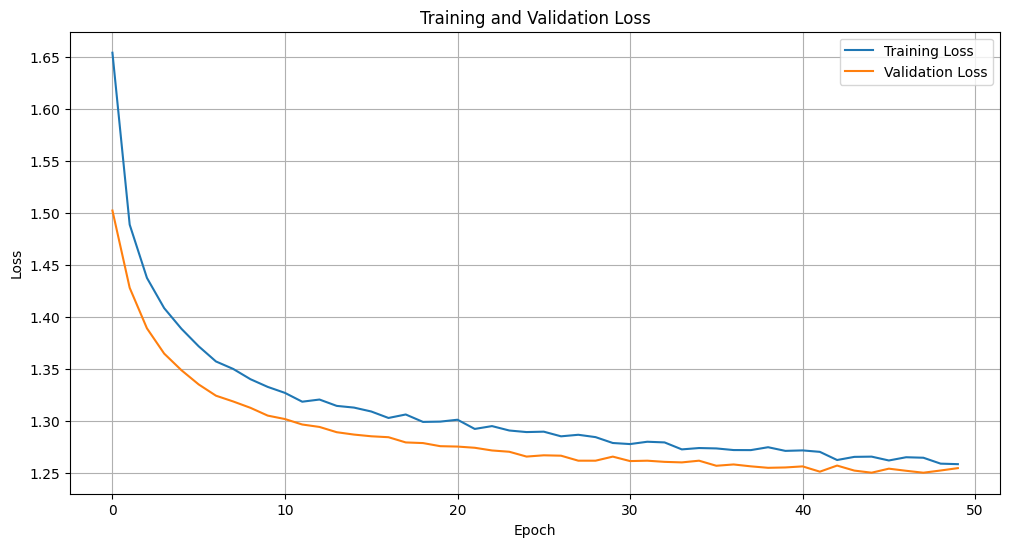

In [14]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

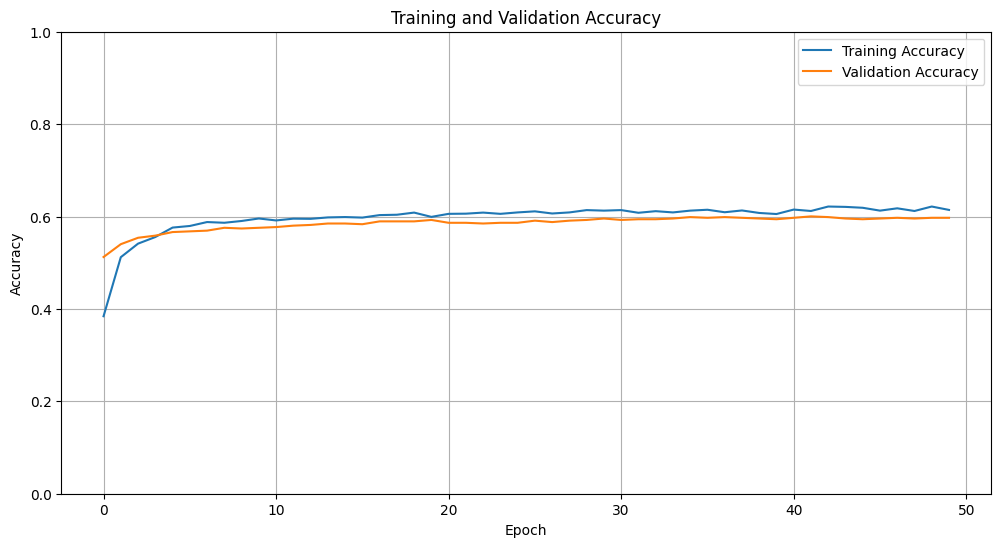

In [ ]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [15]:
# Load models and evaluate on test set on vscode
linear_eval_model_path =  linear_eval_best_model_file_name

# Load both models
# simclr_model = tf.keras.models.load_model(simclr_model_path)
linear_eval_best_model = tf.keras.models.load_model(linear_eval_model_path)

#### Normalize test data

In [16]:
# You can also use it for test data (but should fit the scaler only on training data)
X_test_normalized = normalize_3d_data(np_test_data)

In [17]:
linear_eval_best_model = tf.keras.models.load_model(linear_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(linear_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(linear_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


{'Confusion Matrix': array([[120,   1,   1,   6,   0,   9,   4],
       [  8,  54,   2,   5,   8,  16,   4],
       [ 41,  17,  14,   3,   3,  16,   2],
       [ 21,   1,   4,  81,   0,  11,   5],
       [  0,   3,   2,   3, 111,   1,   3],
       [ 44,   1,   2,   2,   0,  54,  13],
       [ 65,   3,   9,   5,   3,  31,  13]]), 'F1 Macro': 0.5074545894587686, 'F1 Micro': 0.5418181818181819, 'F1 Weighted': 0.5127056340586985, 'Precision': 0.5477557090333852, 'Recall': 0.5258380341403229, 'Kappa': np.float64(0.45997007626396613)}
Model in last epoch
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
{'Confusion Matrix': array([[121,   1,   1,   6,   0,   9,   3],
       [  8,  54,   2,   5,   8,  17,   3],
       [ 42,  16,  15,   3,   3,  15,   2],
       [ 23,   1,   4,  80,   0,  11,   4],
       [  0,   3,   2,   3, 111,   1,   3],
       [ 45,   1,   1,   2,   0,  55,  12],
       [ 68,   3,   9,   4,   3,  31,  11]]), 'F1 Macro': 0.507259876270339, 'F1 Micro': 0.5418181818181819, 'F1 Weighted

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


### 1.2.2 Full HAR Model

#### Train

In [18]:
total_epochs = 50
batch_size = 200
tag = "full_eval"

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
full_evaluation_model = simclr_models.create_full_classification_model_from_base_model(
    simclr_model, output_shape, model_name="TPN", intermediate_layer=7, last_freeze_layer=4)

full_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"

best_model_callback = tf.keras.callbacks.ModelCheckpoint(full_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = full_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - auc: 0.7263 - categorical_accuracy: 0.3695 - loss: 1.6650 - precision: 0.7442 - recall: 0.1543 - val_auc: 0.8504 - val_categorical_accuracy: 0.5121 - val_loss: 1.3021 - val_precision: 0.8350 - val_recall: 0.2606
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - auc: 0.8500 - categorical_accuracy: 0.4975 - loss: 1.3164 - precision: 0.7565 - recall: 0.2632 - val_auc: 0.8632 - val_categorical_accuracy: 0.5333 - val_loss: 1.2497 - val_precision: 0.8349 - val_recall: 0.2682
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - auc: 0.8640 - categorical_accuracy: 0.5213 - loss: 1.2492 - precision: 0.7826 - recall: 0.3153 - val_auc: 0.8681 - val_categorical_accuracy: 0.5424 - val_loss: 1.2305 - val_precision: 0.8253 - val_recall: 0.2864
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - auc: 0.8745 - categorical_accuracy: 0.5462 - loss: 1.2002 - precision: 0.8161 - recall: 0.3379 - val_auc: 0.8690 - val_categorical_accuracy: 0.5455 - val_loss: 1.2

#### Plot metrics

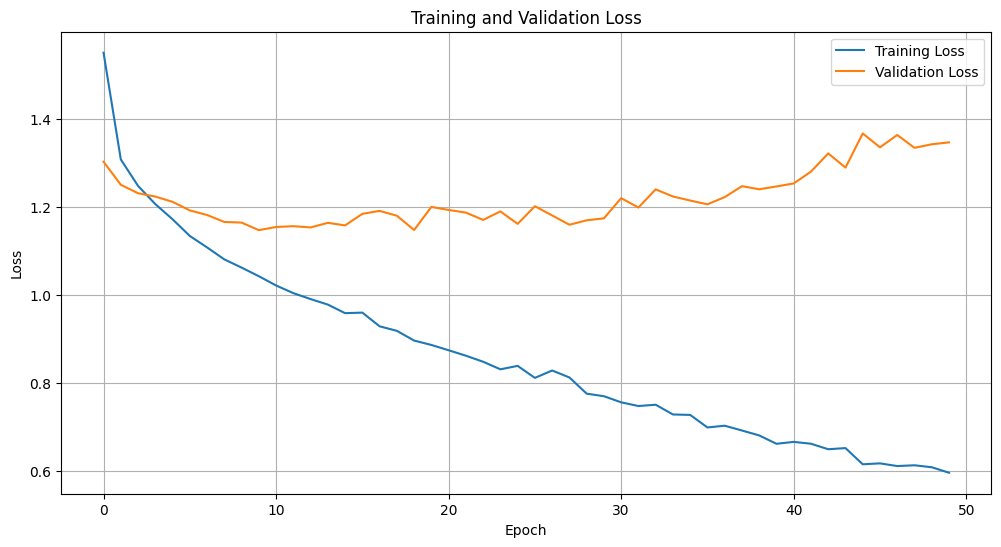

In [19]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

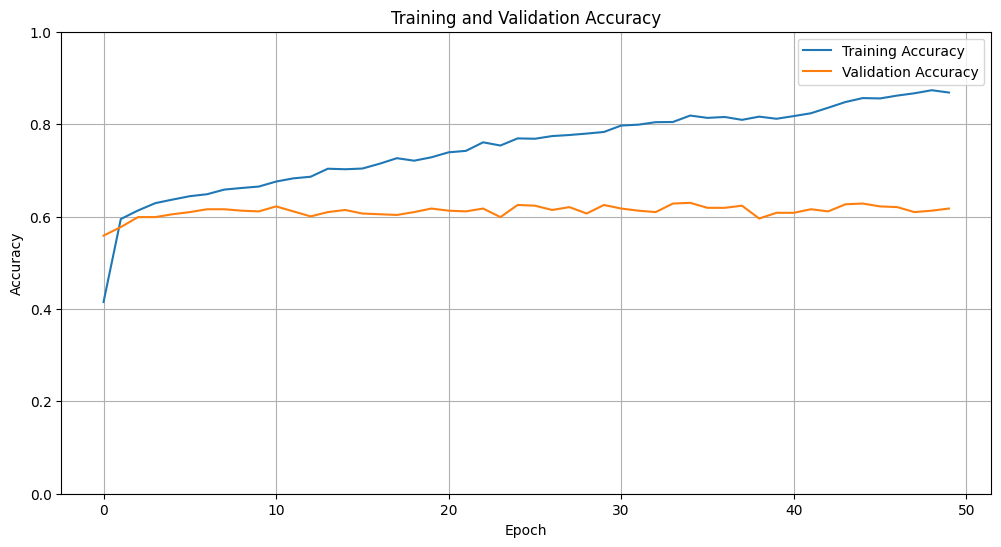

In [ ]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [20]:
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(full_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(full_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


{'Confusion Matrix': array([[112,   1,   2,   5,   1,  15,   5],
       [ 10,  71,   0,   3,   6,   6,   1],
       [ 29,  15,  26,   4,   2,  16,   4],
       [ 16,   5,   4,  81,   0,  11,   6],
       [  0,   6,   0,   2, 115,   0,   0],
       [ 30,   4,   5,   9,   0,  56,  12],
       [ 54,   8,  10,   5,   1,  34,  17]]), 'F1 Macro': 0.5547282386967429, 'F1 Micro': 0.5793939393939394, 'F1 Weighted': 0.5555619355309487, 'Precision': 0.5845079027915112, 'Recall': 0.5721651198200174, 'Kappa': np.float64(0.5059598900349811)}
Model in last epoch
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


{'Confusion Matrix': array([[ 70,   1,  20,   8,   0,   9,  33],
       [  6,  72,   2,   4,   3,   6,   4],
       [ 11,  15,  25,   5,   1,  21,  18],
       [  6,   2,   7,  88,   0,   8,  12],
       [  0,   3,   0,   0, 119,   0,   1],
       [  7,   6,  13,   6,   0,  55,  29],
       [ 23,   3,  20,   7,   0,  32,  44]]), 'F1 Macro': 0.5708836215971433, 'F1 Micro': 0.5733333333333334, 'F1 Weighted': 0.5742100361905228, 'Precision': 0.5724986883330355, 'Recall': 0.5710412343190864, 'Kappa': np.float64(0.5010377864221798)}


## Extra: t-SNE Plots

### Parameters

In [21]:
import sklearn.manifold
import seaborn as sns

### t-SNE Representations

In [22]:
# First load the model from the file path
target_model_path = simclr_model_save_path
loaded_model = tf.keras.models.load_model(target_model_path)
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(loaded_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(X_test_normalized, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "base_model_simclr_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 84,416 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(600, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 825 samples in 0.000s...
[t-SNE] Computed neighbors for 825 samples in 0.322s...
[t-SNE] Computed conditional probabilities for sample 825 / 825
[t-SNE] Mean sigma: 1.609893
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.563572
[t-SNE] KL divergence after 1000 iterations: 0.611223


### Plotting

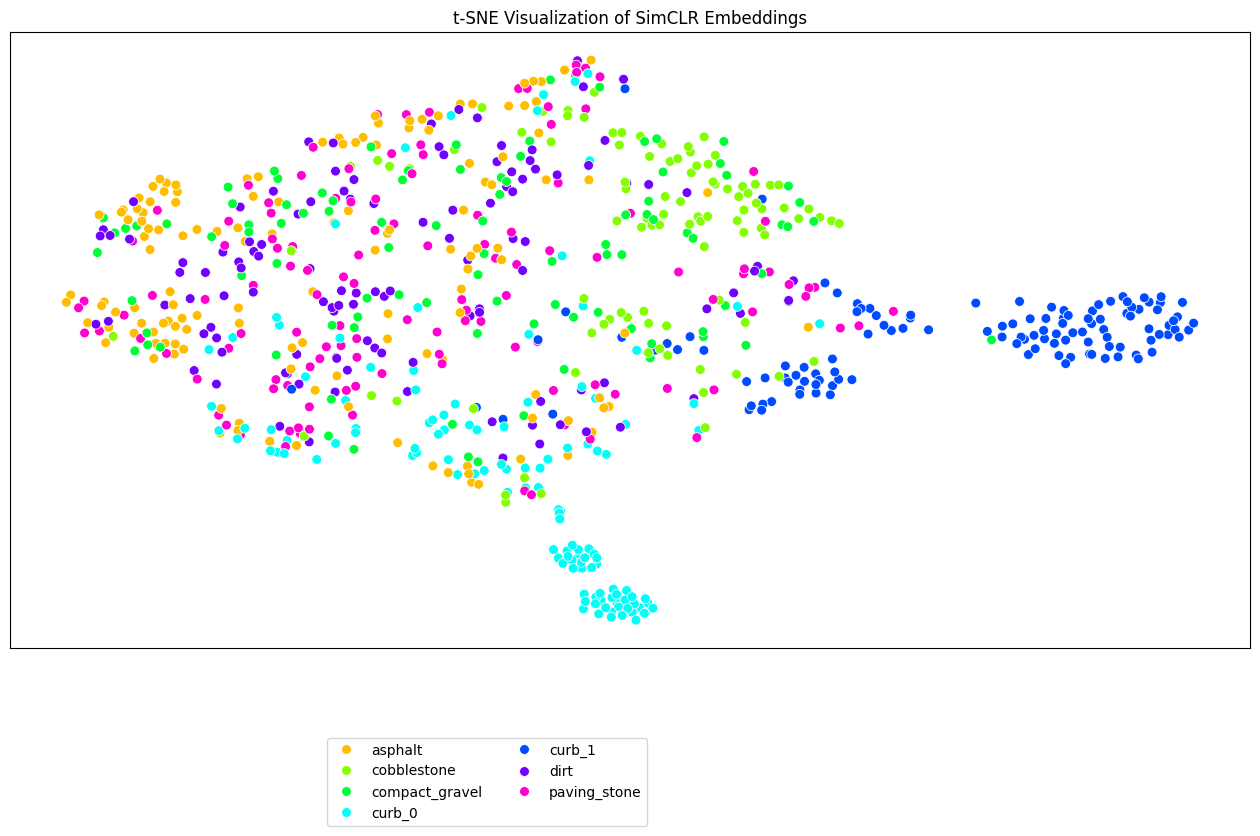

In [23]:
# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_labels, axis=1)
unique_labels = np.unique(labels_argmax)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=sns.color_palette("hsv", len(unique_labels)),
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# If you have class names, use them for the legend
# Define your activity names if needed
label_list_full_name = ["asphalt", "cobblestone", "compact_gravel", "curb_0", "curb_1", "dirt", "paving_stone"]  # Replace with your actual class names

# Update legend with class names if available
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():  # Check if variable exists
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)

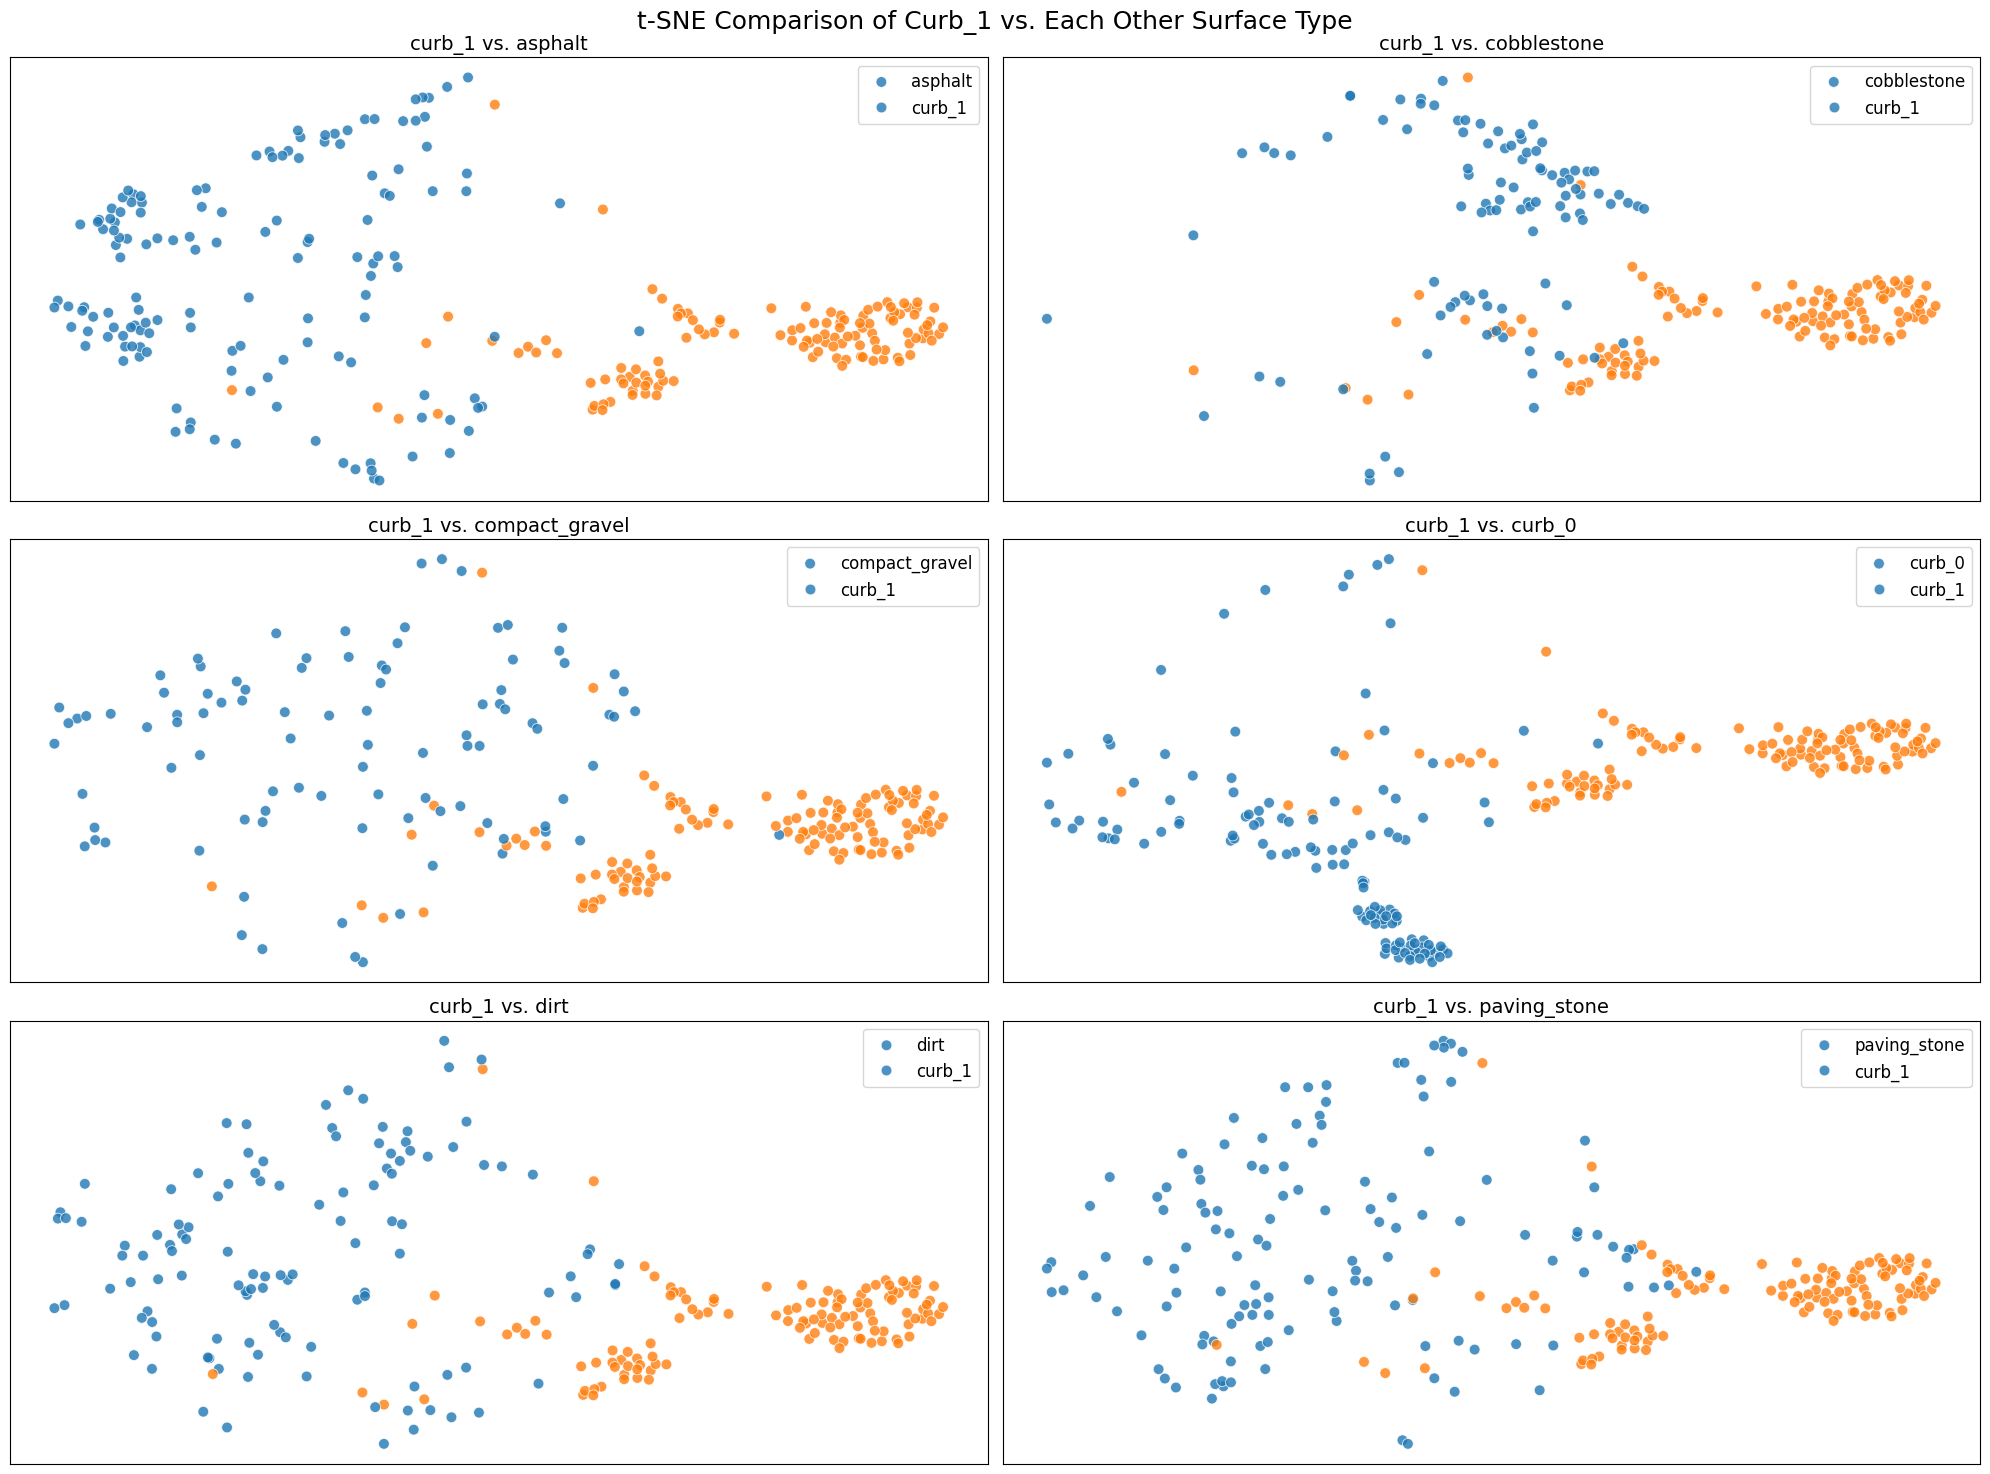

In [24]:
# Create a figure with 6 subplots (3x2 grid) to compare curb_1 with each other class
plt.figure(figsize=(20, 15))

# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_labels, axis=1)
unique_labels = np.unique(labels_argmax)
curb_1_index = 4  # Based on your label_list_full_name where "curb_1" is at index 4

# Define your surface type names
label_list_full_name = ["asphalt", "cobblestone", "compact_gravel", "curb_0", "curb_1", "dirt", "paving_stone"]

# Loop through each class (except curb_1) and create a subplot
subplot_index = 1
for class_index in unique_labels:
    # Skip curb_1 as we're comparing others against it
    if class_index == curb_1_index:
        continue

    # Create binary mask for current pair (curb_1 and current class)
    mask = np.logical_or(labels_argmax == curb_1_index, labels_argmax == class_index)

    # Create binary labels: 0 for current class, 1 for curb_1
    binary_labels = np.zeros(np.sum(mask))
    binary_labels[labels_argmax[mask] == curb_1_index] = 1

    # Get the filtered t-SNE projections
    filtered_projections = tsne_projections[mask]

    # Create subplot
    plt.subplot(3, 2, subplot_index)

    # Plot the scatter points
    sns.scatterplot(
        x=filtered_projections[:, 0],
        y=filtered_projections[:, 1],
        hue=binary_labels,
        palette=["#1f77b4", "#ff7f0e"],  # Blue for other class, Orange for curb_1
        s=60,
        alpha=0.8
    )

    # Remove axes ticks for cleaner visualization
    plt.xticks([], [])
    plt.yticks([], [])

    # Set subplot title
    plt.title(f"curb_1 vs. {label_list_full_name[class_index]}", fontsize=14)

    # Custom legend
    plt.legend([label_list_full_name[class_index], "curb_1"], fontsize=12)

    # Increment subplot index
    subplot_index += 1

# Add overall title
plt.suptitle("t-SNE Comparison of Curb_1 vs. Each Other Surface Type", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()